In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.preprocessing as StandardScaler
from sklearn.cluster import KMeans

In [ ]:
# load the data
df=pd.read_excel('/content/ml_model.xlsx')

df.head(5)

,customer_id,register_to_order,first_to_last_order,total_spend,total_unit
0,C111795L,-151,31,215760.0,2
1,C111808L,-10,0,229100.0,1
2,C112088L,156,0,5800000.0,4
3,C112612L,6,0,278400.0,1
4,C112901L,13,0,57942.0,1


In [ ]:
#Group registered First
df_normal=df[df['register_to_order']>=0].copy()

#Group pr_registeration
df_pre__register=df[df['register_to_order']<0].copy()

print('Noraml Customer: ',df_normal.shape[0])
print('Pre-Register Customer: ',df_pre__register.shape[0])

Noraml Customer:  1984
Pre-Register Customer:  880


In [ ]:
features=['register_to_order',
          'first_to_last_order',
          'total_unit',
          'total_spend'
          ]

In [ ]:
from sklearn.preprocessing import StandardScaler
#Standarization
scaler_normal=StandardScaler()
X_normal_scaled=scaler_normal.fit_transform(df_normal[features])

scaler_pre=StandardScaler()
X_pre_scaled=scaler_pre.fit_transform(df_pre__register[features])

In [ ]:
#train The Model
kmeans=KMeans(n_clusters=3,random_state=42)
df_normal['cluster']= kmeans.fit_predict(X_normal_scaled)

In [ ]:

kmeans_pre=KMeans(n_clusters=3,random_state=42)
df_pre__register['cluster']= kmeans_pre.fit_predict(X_pre_scaled)

In [ ]:
#Summery of the model rgistere_to_order
cluster_summery=(df_normal.groupby('cluster')[features].mean().round(2))
cluster_summery

,register_to_order,first_to_last_order,total_unit,total_spend
cluster,,,,
0,31.01,16.73,2.42,1.004454e+06
1,77.00,0.00,1000.00,5.187520e+08
2,226.10,7.17,2.29,5.416025e+05


In [ ]:
#Summery of the model pre register
cluster_pre_summery=(df_pre__register.groupby('cluster')[features].mean().round(2))
cluster_pre_summery

,register_to_order,first_to_last_order,total_unit,total_spend
cluster,,,,
0,-26.60,17.37,1.71,699569.34
1,-128.63,480.98,25.46,19156649.85
2,-172.00,43.04,2.03,705395.04


In [ ]:
#Mapping
cluster_label={
    0:"Normal but low Engagement",
    1:"Extreme High_Volume",
    2:"Loyal, High_Value Customer"
}

df_normal["segment"]=df_normal["cluster"].map(cluster_label)
df_normal.head(5)

,customer_id,register_to_order,first_to_last_order,total_spend,total_unit,cluster,segment
2,C112088L,156,0,5800000.0,4,2,"Loyal, High_Value Customer"
3,C112612L,6,0,278400.0,1,0,Normal but low Engagement
4,C112901L,13,0,57942.0,1,0,Normal but low Engagement
5,C113061L,194,305,507442.0,3,2,"Loyal, High_Value Customer"
8,C114466L,192,0,174000.0,3,2,"Loyal, High_Value Customer"


In [ ]:
#Mapping of pre_register
cluster_label={
    0:"Normal but low Engagement",
    1:"Extreme High_Volume",
    2:"Loyal, High_Value Customer"
}

df_pre__register["segment"]=df_pre__register["cluster"].map(cluster_label)
df_pre__register.head(5)

,customer_id,register_to_order,first_to_last_order,total_spend,total_unit,cluster,segment
0,C111795L,-151,31,215760.0,2,2,"Loyal, High_Value Customer"
1,C111808L,-10,0,229100.0,1,0,Normal but low Engagement
6,C113448L,-6,0,151380.0,3,0,Normal but low Engagement
7,C113767L,-248,0,980200.0,1,2,"Loyal, High_Value Customer"
11,C115156L,-14,0,230840.0,2,0,Normal but low Engagement


<Axes: xlabel='total_spend', ylabel='total_unit'>

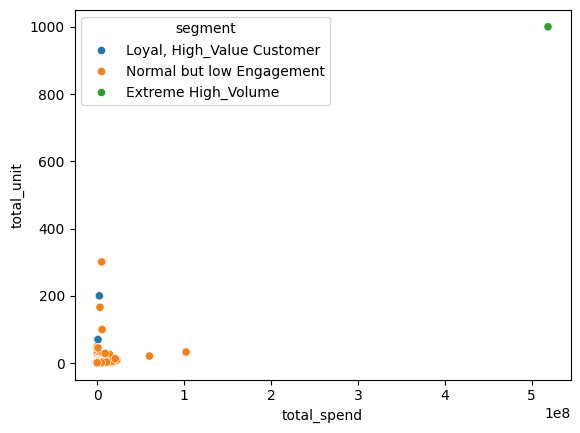

In [ ]:
#visualize the data
sns.scatterplot(
    data=df_normal,
    x='total_spend',
    y='total_unit',
    hue='segment',
    palette='tab10'
    )

<Axes: xlabel='total_spend', ylabel='total_unit'>

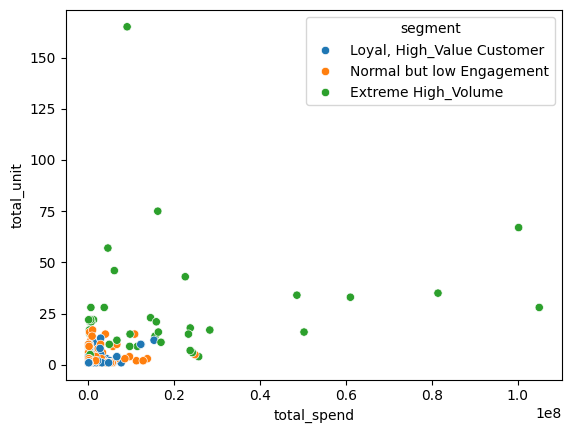

In [ ]:
#visualize the data
sns.scatterplot(
    data=df_pre__register,
    x='total_spend',
    y='total_unit',
    hue='segment',
    palette='tab10'
    )

In [ ]:
#combine the data
df_normal['segment_type']='normal'
df_pre__register['segment_type']='pre_register'


In [ ]:
df_segmented=pd.concat([df_normal,df_pre__register])
df_segmented.head(5)

,customer_id,register_to_order,first_to_last_order,total_spend,total_unit,cluster,segment,segment_type
2,C112088L,156,0,5800000.0,4,2,"Loyal, High_Value Customer",normal
3,C112612L,6,0,278400.0,1,0,Normal but low Engagement,normal
4,C112901L,13,0,57942.0,1,0,Normal but low Engagement,normal
5,C113061L,194,305,507442.0,3,2,"Loyal, High_Value Customer",normal
8,C114466L,192,0,174000.0,3,2,"Loyal, High_Value Customer",normal


In [ ]:
df_segmented.tail(5)

,customer_id,register_to_order,first_to_last_order,total_spend,total_unit,cluster,segment,segment_type
2852,C995967L,-74,97,67802.0,2,0,Normal but low Engagement,pre_register
2858,C997231L,-11,0,49880.0,1,0,Normal but low Engagement,pre_register
2859,C997696L,-126,0,109910.0,1,2,"Loyal, High_Value Customer",pre_register
2861,C998685L,-198,0,116000.0,1,2,"Loyal, High_Value Customer",pre_register
2863,C998847L,-145,0,86942.0,1,2,"Loyal, High_Value Customer",pre_register


In [ ]:
#Save the data
df_segmented.to_excel('ml_model_segmented.xlsx',index=False)